In [ ]:
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from src import *

def set_fonts(extra_params={}):
    params = {
        "font.family": "Serif",
        # "font.sans-serif": ["Tahoma", "DejaVu Sans", "Lucida Grande", "Verdana"],
        "mathtext.fontset": "cm",
        "legend.fontsize": 16,
        "legend.title_fontsize": 14,
        "axes.labelsize": 28,
        "axes.titlesize": 28,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "figure.titlesize": 20,
    }
    for key, value in extra_params.items():
        params[key] = value
    pylab.rcParams.update(params)

set_fonts()

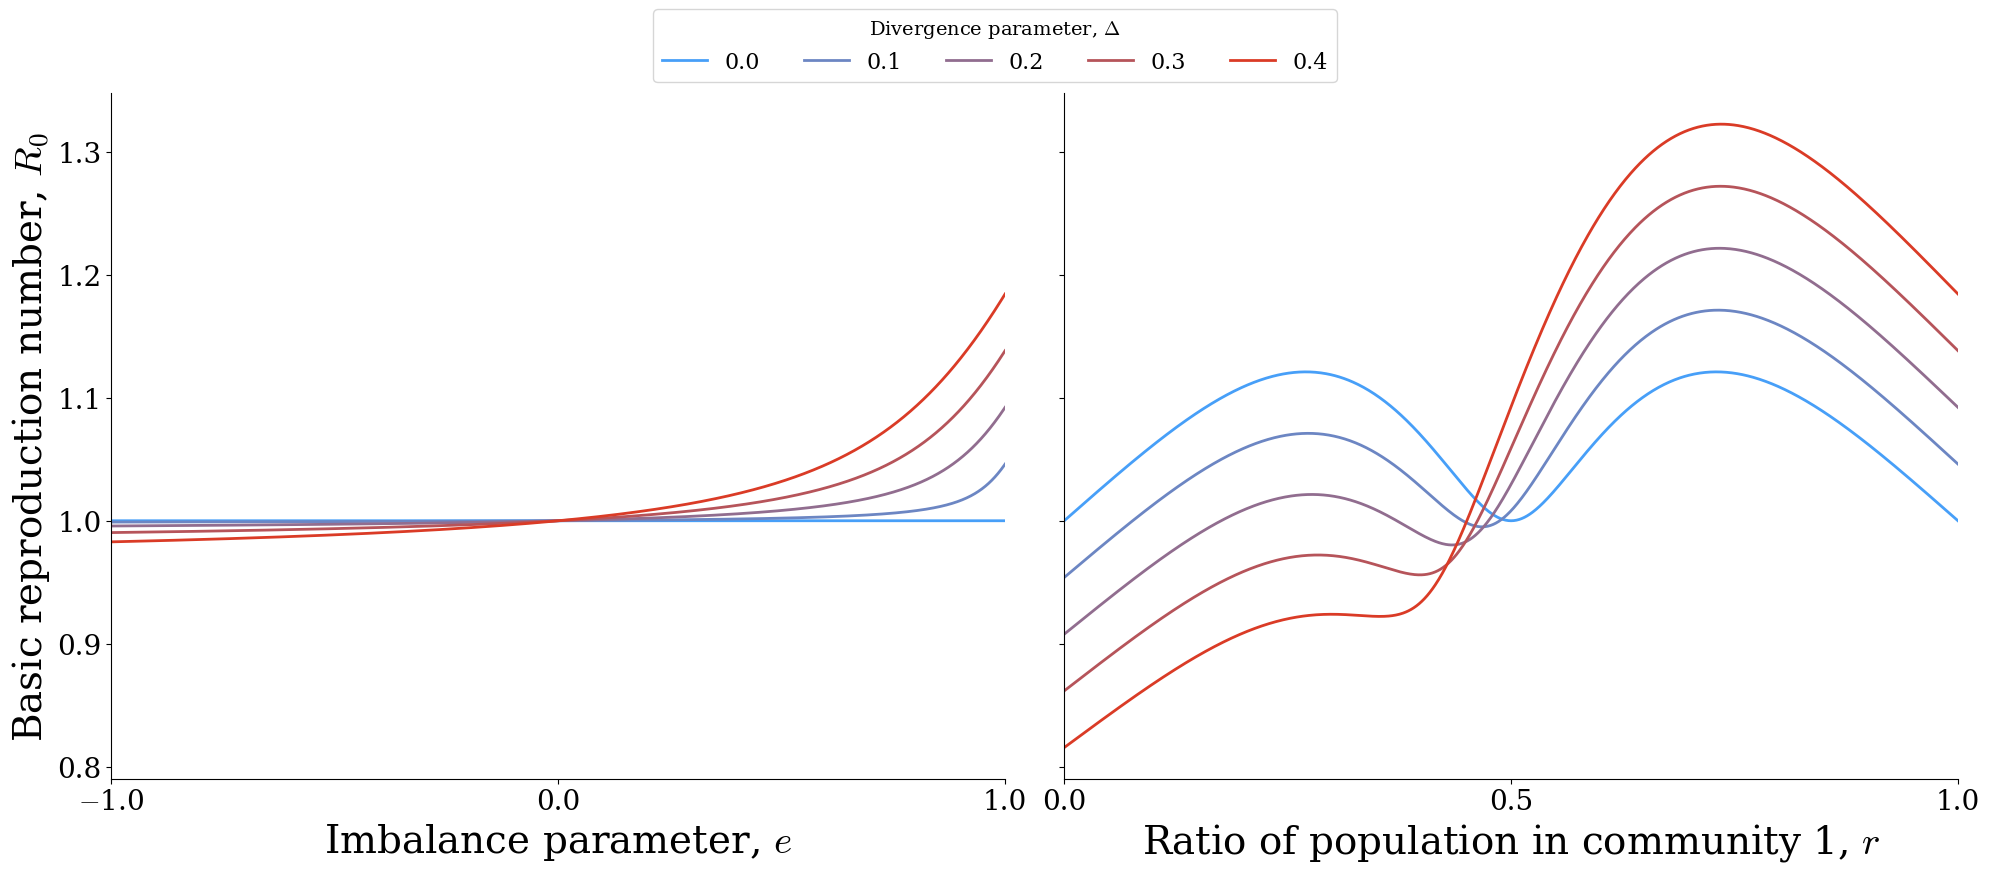

In [2]:
colors = sns.color_palette("blend:#479FF8,#DA3B26", n_colors=5)

eps = np.linspace(0, 3, 100)
dels = np.linspace(0, 3, 100)

k = 10
R0 = 1.0
gamma = 0.1

mean_a = eps @ create_comm(0) @ dels

beta = IBC_beta(mean_a, mean_a, R0, gamma, k, e=0, r=0.5)

rep_num_e = []
for j, e in enumerate(np.linspace(-1, 1, 2001)):
    rep_tmp = []
    for i, del_a in enumerate(np.linspace(0, 0.4, 5)):
        rep_tmp.append(
            IBC_r0(
                mean_a + np.round(del_a, 2),
                mean_a - np.round(del_a, 2),
                beta,
                gamma,
                k,
                e,
                0.5
            )
        )
    rep_num_e.append(rep_tmp)

beta = IBC_beta(mean_a, mean_a, R0, gamma, k, e=0.8, r=0.5)

rep_num_r = []
for j, r in enumerate(np.linspace(0, 1, 1001)):
    rep_tmp = []
    for i, del_a in enumerate(np.linspace(0, 0.4, 5)):
        rep_tmp.append(
            IBC_r0(
                mean_a + np.round(del_a, 2),
                mean_a - np.round(del_a, 2),
                beta,
                gamma,
                k,
                0.8,
                r
            )
        )
    rep_num_r.append(rep_tmp)

fig, ax = plt.subplots(figsize=(20, 8), ncols = 2, sharey=True)
for i in range(5):
    ax[0].plot(
        np.linspace(-1, 1, 2001),
        [j[i] for j in rep_num_e],
        color=colors[i],
        label=f"{np.round(np.linspace(0, 0.4, 5)[i], 2)}",
        linewidth = 2
    )

    ax[1].plot(
        np.linspace(0, 1, 1001),
        [j[i] for j in rep_num_r],
        color=colors[i],
        label=f"{np.round(np.linspace(0, 0.4, 5)[i], 2)}",
        linewidth = 2
    )

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title=r"Divergence parameter, $\Delta$",loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=5)
ax[0].set_xlabel(r"Imbalance parameter, $e$")
ax[0].set_ylabel(r"Basic reproduction number, $R_0$")

ax[0].set_xticks([-1.0, 0.0, 1.0], [r"$-$1.0", 0.0, 1.0])
ax[0].set_yticks(np.linspace(0.8, 1.3, 6))

ax[0].set_xlim(-1, 1)

ax[1].set_xlabel(r"Ratio of population in community 1, $r$")

ax[1].set_xticks([0.0, 0.5, 1.0])
ax[1].set_yticks(np.linspace(0.8, 1.3, 6))

ax[1].set_xlim(0, 1)

sns.despine()
plt.tight_layout()

#plt.savefig("../Outputs/Fig2.png", dpi = 1000,bbox_inches='tight')
#plt.savefig("../Outputs/Fig2.svg", format="svg",bbox_inches='tight')
#plt.savefig("../Outputs/Fig2.pdf", format="pdf",bbox_inches='tight')